# Recuperação dos dados

In [1]:
from funcoes_de_analise.abre_corpora import carregar_json_para_dicionario
from funcoes_de_analise.funcao_segmentar_sentencas_com_spacy import segmentar_sentencas
from funcoes_de_analise.stop_words import stop_words

In [ ]:
# Carrega os dados das transcriçõs para um dicionário
transcricoes_dados_dict = carregar_json_para_dicionario("corpora/dados_transcricoes_nikolas.json")

In [ ]:
# String única com todas as transcrições
transcricoes_string_unica = ""
# Lista de strings por transcrição completa
transcricoes_lista_por_texto_completo = []
# Lista de string por sentença
transcricoes_lista_por_sentencas = []

# Laço que itera os dados das transcriçes e preenche as variáveis acim
i = 0
for t in transcricoes_dados_dict:
    i += 1
    print(f'iniciando transcrição: {i}')
    # Cria uma única string com a transcrição
    transcricoes_string_unica += t["transcricao"]
    transcricoes_string_unica += " "
    # Criar uma lista com as transcrições
    transcricoes_lista_por_texto_completo.append(t["transcricao"])

    # Cria uma lista de sentencas das transcrições
    sentencas_da_transcricao_atual = segmentar_sentencas(t["transcricao"])
    transcricoes_lista_por_sentencas = transcricoes_lista_por_sentencas + sentencas_da_transcricao_atual
    del sentencas_da_transcricao_atual
del t, i

In [ ]:
# Para ler JSON

import json
# Para Ler json
with open("corpora/dados_transcricoes_nikolas.json", "r", encoding="utf-8") as f:
    lista_recuperada = json.load(f)

In [ ]:
# Salvar Pickle
import pickle
caminho_arquivo = 'dados.pickle'
# Salvar (Serializar)
with open(caminho_arquivo, 'wb') as arquivo_saida:
    pickle.dump((transcricoes_dados_dict,
                 transcricoes_lista_por_sentencas,
                 transcricoes_lista_por_texto_completo,
                 transcricoes_string_unica), arquivo_saida)

In [2]:
# CARREGAR ARQUIVO PICKLE
# Carrega as princiapais variáveis já processadas, útil para economizar tempo
import pickle

caminho_arquivo = 'dados.pickle'
with open(caminho_arquivo, 'rb') as arquivo_entrada:
   transcricoes_dados_dict, transcricoes_lista_por_sentencas, transcricoes_lista_por_texto_completo,                 transcricoes_string_unica = pickle.load(arquivo_entrada)
del arquivo_entrada, caminho_arquivo


In [ ]:
# Para Ler TXT

with open('corpora/transcricoes_nikolas.txt', 'r', encoding='utf-8') as arquivo:
    transcricoes = arquivo.read() # Lê todo o conteúdo

In [ ]:
# Para Salvar json

#______________________
dicionario =
#______________________

with open("corpora/sentencas.json", "w", encoding="utf-8") as f:
    json.dump(dicionario, f, ensure_ascii=False)

# Tabela 1, 2 e 3 - lexicometria

In [11]:
# TABELA 1 - Lexicometria
# 1 - DETERMINA OS 50 TERMOS MAIS USADOS EM TODO O CORPUS
# Função recebe uma lista de strings e devolve um objeto freqdist da NLTK
from funcoes_de_analise.gera_lista_de_mais_frequentes import gera_lista_de_mais_frequentes
#, "VERB", "PROPN", "ADV", "INTJ"

# Função já retorna os termos lematizados
dicionario_termo_prevalencia = gera_lista_de_mais_frequentes(transcricoes_lista_por_texto_completo, "funcoes_de_analise/pt.txt", 50, {"NOUN","PROPN"}, 200, True)


Processando corpus específico (aguarde)...
Processando corpus de referência (aguarde)...

Nº  Termo         Absoluta  Relativa (%)
--------------------------------------------------
1   gente         6245      5.03     
2   deus          4773      3.84     
3   pessoa        4484      3.61     
4   senhor        4407      3.55     
5   brasil        1991      1.6      
6   vida          1860      1.5      
7   presidente    1807      1.45     
8   deputado      1773      1.43     
9   oração        1598      1.29     
10  cara          1537      1.24     
11  educação      1510      1.22     
12  jesus         1405      1.13     
13  país          1390      1.12     
14  tempo         1355      1.09     
15  palavra       1331      1.07     
16  escola        1243      1.0      
17  fato          1146      0.92     
18  nome          1132      0.91     
19  poder         1056      0.85     
20  igreja        1051      0.85     
21  exemplo       1032      0.83     
22  casa          10

# Busca sentença por termo

In [10]:
from funcoes_de_analise.busca_sentenca_por_lema import buscar_sentencas_por_lema

sentencas = buscar_sentencas_por_lema("cara", transcricoes_lista_por_sentencas, 10)

In [11]:
for s in sentencas:
    print(s)
    print("\n\n")

Não existiu uma outra pessoa que foi tão perseguida, não somente pela mídia, mas principalmente pelo sistema judiciário, que virou um sistema político, para poder calar esse cara, censurar para prender seus aliados, para poder fazer com que ele não esteja na corrida eleitoral.



Em Verdade porque é isso que ele quer da Gente vou fechar meu microfone aqui porque eu não quero atrapalhar o louvor e eu vou cantar aqui beleza no mundo [Música] [Música] Jesus [Música] [Música] [Música] [Música] [Música] eu não sabia que você ia falar dessa canção não não esperava que fosse essa geralmente falam de outras canções e essa campanha de um amigo Felipe Dutra a gente sempre em algum álbum a gente sempre pega alguma canção que eu falo assim cara essa música eu deveria ter escrito mas alguém ouviu ela primeiro que eu e meu amigo foi feito de Dutra e ele ele tem essa canção eu pedi para ele para a gente gravar e a gente sempre recebe a pergunta isso que não tava programado a gente sempre recebe Pergu

# Grafico 1 (dendograma) e tabela 2 (prevalência)
Dendograma de Vetores de proximidade semântica


## Gráfico 1 - Dendograma

In [10]:
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage

In [6]:
# SALVAR PICLE DICIONARIO DE PREVALENCIA

# Salvar Pickle
import pickle
caminho_arquivo = 'dicionario_prevalencia.pickle'
# Salvar (Serializar)
with open(caminho_arquivo, 'wb') as arquivo_saida:
    pickle.dump(dicionario_termo_prevalencia, arquivo_saida)

In [ ]:
# CARREGAR PICKLE DICIONARIO DE PREVALENCIA

caminho_arquivo = 'dicionario_prevalencia.pickle'
with open(caminho_arquivo, 'rb') as arquivo_entrada:
   transcricoes_dados_dict, transcricoes_lista_por_sentencas, transcricoes_lista_por_texto_completo,                 transcricoes_string_unica = pickle.load(arquivo_entrada)
del arquivo_entrada, caminho_arquivo


In [3]:
# 1 - DETERMINA OS 50 TERMOS MAIS USADOS EM TODO O CORPUS
# Função recebe uma lista de strings e devolve um objeto freqdist da NLTK
from funcoes_de_analise.gera_lista_de_mais_frequentes import gera_lista_de_mais_frequentes

# Função já retorna os termos lematizados
dicionario_termo_prevalencia = gera_lista_de_mais_frequentes(transcricoes_lista_por_texto_completo, "funcoes_de_analise/pt.txt", 50, {"NOUN","PROPN"}, 200, True)

Processando corpus específico (aguarde)...
Processando corpus de referência (aguarde)...

Nº  Termo         Absoluta  Relativa (%)
--------------------------------------------------
1   gente         6245      5.03     
2   deus          4773      3.84     
3   pessoa        4484      3.61     
4   senhor        4407      3.55     
5   brasil        1991      1.6      
6   vida          1860      1.5      
7   presidente    1807      1.45     
8   deputado      1773      1.43     
9   oração        1598      1.29     
10  cara          1537      1.24     
11  educação      1510      1.22     
12  jesus         1405      1.13     
13  país          1390      1.12     
14  tempo         1355      1.09     
15  palavra       1331      1.07     
16  escola        1243      1.0      
17  fato          1146      0.92     
18  nome          1132      0.91     
19  poder         1056      0.85     
20  igreja        1051      0.85     
21  exemplo       1032      0.83     
22  casa          10

In [4]:
# TESTE
# Determina a prevalencia de um termos na % do corpora
from funcoes_de_analise.N_prevalencia_termo_em_corpora import prevalencia_termo_em_corpora

termos_mais_usados = [chave for chave, valor in dicionario_termo_prevalencia.items()]

# Entra uma lista de termos [string] e uma lista de transcrições [string]
x = prevalencia_termo_em_corpora(termos_mais_usados, transcricoes_lista_por_texto_completo)


Iniciando corpus 1/475
Iniciando corpus 2/475
Iniciando corpus 3/475
Iniciando corpus 4/475
Iniciando corpus 5/475
Iniciando corpus 6/475
Iniciando corpus 7/475
Iniciando corpus 8/475
Iniciando corpus 9/475
Iniciando corpus 10/475
Iniciando corpus 11/475
Iniciando corpus 12/475
Iniciando corpus 13/475
Iniciando corpus 14/475
Iniciando corpus 15/475
Iniciando corpus 16/475
Iniciando corpus 17/475
Iniciando corpus 18/475
Iniciando corpus 19/475
Iniciando corpus 20/475
Iniciando corpus 21/475
Iniciando corpus 22/475
Iniciando corpus 23/475
Iniciando corpus 24/475
Iniciando corpus 25/475
Iniciando corpus 26/475
Iniciando corpus 27/475
Iniciando corpus 28/475
Iniciando corpus 29/475
Iniciando corpus 30/475
Iniciando corpus 31/475
Iniciando corpus 32/475
Iniciando corpus 33/475
Iniciando corpus 34/475
Iniciando corpus 35/475
Iniciando corpus 36/475
Iniciando corpus 37/475
Iniciando corpus 38/475
Iniciando corpus 39/475
Iniciando corpus 40/475
Iniciando corpus 41/475
Iniciando corpus 42/475
I

In [7]:
dicionario_teste = {}

i = 0
for chave, valor in dicionario_termo_prevalencia.items():
    i += 1
    try:
        print(f"{i} {chave:<15} {valor:<10} {x[chave][1]:10} {(valor+1) * (float(x[chave][1][:-1]))}")
        dicionario_teste[chave] = (valor, float(x[chave][1][:-1]), (valor+1) * (float(x[chave][1][:-1])))
    except:
                print(f"{i} {chave:<15} {valor:<10} ------")
                dicionario_teste[chave] = (valor, 1, 1)

1 gente           5.03       74.9%      451.64700000000005
2 deus            3.84       48.8%      236.19199999999998
3 pessoa          3.61       81.7%      376.63699999999994
4 senhor          3.55       41.1%      187.005
5 brasil          1.6        68.4%      177.84000000000003
6 vida            1.5        ------
7 presidente      1.45       49.9%      122.25500000000001
8 deputado        1.43       37.7%      91.61099999999999
9 oração          1.29       15.6%      35.724
10 cara            1.24       ------
11 educação        1.22       18.9%      41.95799999999999
12 jesus           1.13       21.5%      45.794999999999995
13 país            1.12       55.6%      117.87200000000001
14 tempo           1.09       50.5%      105.54499999999999
15 palavra         1.07       30.3%      62.72100000000001
16 escola          1.0        24.4%      48.8
17 fato            0.92       58.7%      112.70400000000001
18 nome            0.91       39.4%      75.254
19 poder           0.85    

In [12]:
# 2 - TRATA DOS DADOS PARA DENDOGRAMA

substantivos_mais_frequentes = [chave for chave in dicionario_termo_prevalencia]

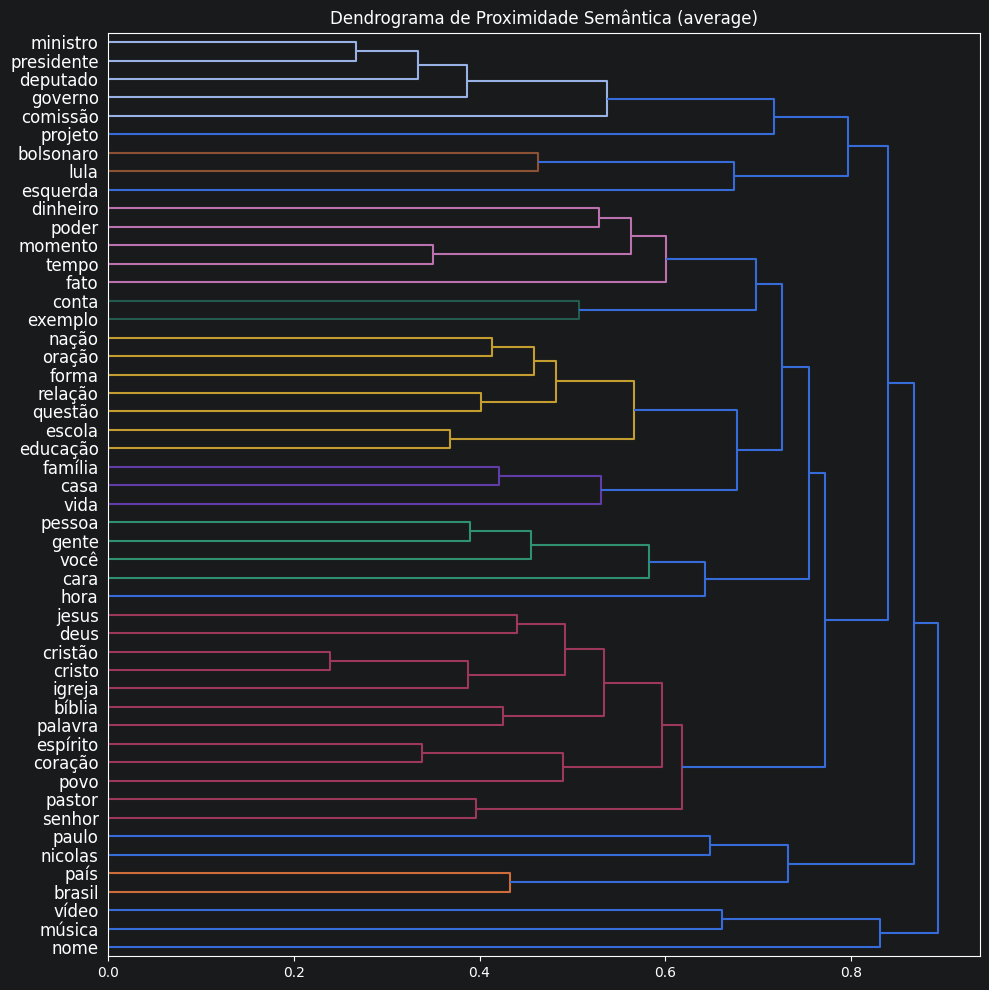

In [13]:
# 3 - GERA O DENDOGRAMA

# 2. Extrai os vetores semânticos ignorando palavras fora do vocabulário do modelo
vetores = []
palavras_validas = []

nlp = spacy.load("pt_core_news_lg")

for p in substantivos_mais_frequentes:
    token = nlp(p)[0]
    if token.has_vector:
        vetores.append(token.vector)
        palavras_validas.append(p)

vetores = np.array(vetores)

# 3. Calcular a matriz de Distância do Cosseno entre todas as palavras
matriz_distancia = cosine_distances(vetores)

# Condensar a matriz quadrada em um vetor 1D
matriz_condensada = squareform(matriz_distancia)

metodo = "average" # "single", "complete", "average", "weighted", "centroid", "median", "ward"]

# 4. Processar o Agrupamento Hierárquico (o método 'ward' minimiza a variância dentro dos grupos)
agrupamento = linkage(matriz_condensada, method=metodo)

# 5. Gerar a visualização (Dendrograma)
plt.figure(figsize=(10, 10))
plt.title(f"Dendrograma de Proximidade Semântica ({metodo})")
dendrogram(
    agrupamento,
    labels=palavras_validas,
    orientation="right",
    leaf_rotation=0,
    leaf_font_size=12
)
plt.tight_layout()
plt.show()


## Tabela 2 - Prevalência
Prevalência por grupo de proximidade semântica.

**ATENçÃO** - os dados da tabela 2 depende de dados do gráfico 1 *

In [14]:
# Adicione esta importação no topo do seu arquivo
from scipy.cluster.hierarchy import fcluster
from collections import defaultdict

# ... (seu código anterior até a criação da variável 'agrupamento') ...

# 1. Calcular o ponto de corte idêntico ao das cores do dendrograma (70% da distância máxima)
distancia_maxima = max(agrupamento[:, 2])
corte_padrao = 0.7 * distancia_maxima

# 2. Gerar uma array com o ID do cluster para cada palavra
# A ordem dos IDs retornados corresponde exatamente à ordem da lista 'palavras_validas'
ids_clusters = fcluster(agrupamento, corte_padrao, criterion='distance')

# 3. Agrupar as palavras por ID do cluster
dicionario_clusters = defaultdict(list)
for palavra, id_cluster in zip(palavras_validas, ids_clusters):
    dicionario_clusters[id_cluster].append(palavra)

# 4. Transformar o dicionário no formato final exigido: Lista de Tuplas
# Formato de saída: [ (1, ('palavra1', 'palavra2')), (2, ('palavra3', 'palavra4')) ]
lista_de_tuplas_clusters = []
for id_cluster, palavras in dicionario_clusters.items():
    lista_de_tuplas_clusters.append((id_cluster, tuple(palavras)))

# Exibir a estrutura de dados final no terminal
for id_cluster, tupla_de_palavras in lista_de_tuplas_clusters:
    print(f"Cluster {id_cluster}: {tupla_de_palavras}")



Cluster 8: ('gente', 'pessoa', 'cara', 'você')
Cluster 7: ('deus', 'senhor', 'jesus', 'palavra', 'igreja', 'coração', 'bíblia', 'povo', 'espírito', 'cristo', 'pastor', 'cristão')
Cluster 4: ('brasil', 'país')
Cluster 10: ('vida', 'casa', 'família')
Cluster 16: ('presidente', 'deputado', 'governo', 'comissão', 'ministro')
Cluster 11: ('oração', 'educação', 'escola', 'forma', 'questão', 'nação', 'relação')
Cluster 13: ('tempo', 'fato', 'poder', 'momento', 'dinheiro')
Cluster 3: ('nome',)
Cluster 12: ('exemplo', 'conta')
Cluster 14: ('lula', 'bolsonaro')
Cluster 1: ('música',)
Cluster 15: ('esquerda',)
Cluster 5: ('nicolas',)
Cluster 17: ('projeto',)
Cluster 9: ('hora',)
Cluster 2: ('vídeo',)
Cluster 6: ('paulo',)


In [15]:
# Imprime a tabela final

prevalencia_clusters ={}

for id_clusterm, tupla_de_palavras in lista_de_tuplas_clusters:
    dic_palavras_x_prevalencias = {}
    for palavra in tupla_de_palavras:
        dic_palavras_x_prevalencias[palavra] = dicionario_termo_prevalencia[palavra]
    prevalencia_clusters[f'Cluster {id_clusterm}'] = dic_palavras_x_prevalencias

In [16]:
# 1. Ordena o dicionário numericamente pelo número do cluster
clusters_ordenados = sorted(prevalencia_clusters.items(), key=lambda item: int(item[0].split()[1]))

# 2. Itera, formata e imprime os dados
for nome_cluster, palavras in clusters_ordenados:
    # Extrai as chaves (palavras) e junta com vírgula
    lista_nomes = ", ".join(palavras.keys())
    texto_principal = f"{nome_cluster} ({lista_nomes})"

    # Soma os valores decimais que já representam as porcentagens
    porcentagem = sum(palavras.values())

    # Formata a porcentagem com 2 casas decimais e substitui o ponto por vírgula
    porcentagem_str = f"{porcentagem:.2f}%".replace('.', ',')

    # Imprime com alinhamento: <70 reserva 70 caracteres alinhados à esquerda; >7 alinha à direita
    print(f"{texto_principal:<70} {porcentagem_str:>7}")

Cluster 1 (música)                                                       0,76%
Cluster 2 (vídeo)                                                        0,50%
Cluster 3 (nome)                                                         0,91%
Cluster 4 (brasil, país)                                                 2,72%
Cluster 5 (nicolas)                                                      0,70%
Cluster 6 (paulo)                                                        0,41%
Cluster 7 (deus, senhor, jesus, palavra, igreja, coração, bíblia, povo, espírito, cristo, pastor, cristão)  13,73%
Cluster 8 (gente, pessoa, cara, você)                                   10,27%
Cluster 9 (hora)                                                         0,51%
Cluster 10 (vida, casa, família)                                         3,08%
Cluster 11 (oração, educação, escola, forma, questão, nação, relação)    5,79%
Cluster 12 (exemplo, conta)                                              1,42%
Cluster 13 (temp

# Gráfico 2

Gráfico de área, evolução do uso dos termos.

## Etapa 1

In [3]:
import pandas as pd
import re
import spacy


lista_termos = ['senhor', 'pai', 'jesus', 'deus', 'pessoas', 'tempo', 'coisas', 'coração', 'presidente', 'deputado', 'esquerda', 'bolsonaro', 'educação', 'pessoa', 'verdade', 'forma', 'brasil', 'país', 'mundo', 'oração', 'igreja', 'música', 'dia', 'anos', 'fato', 'exemplo', 'casa', 'família', 'nicolas', "lula"]


# 1. Carregar o modelo grande do spaCy
nlp = spacy.load("pt_core_news_lg")

# 2. Converter a lista de dicionários no DataFrame do Pandas e ordenar por data
df = pd.DataFrame(transcricoes_dados_dict)
df['data_criacao'] = pd.to_datetime(df['data_criacao'])
df = df.sort_values('data_criacao')

# Listas auxiliares para armazenar os resultados da iteração
total_substantivos_proprios_por_video = []
contagens_termos = {termo: [] for termo in lista_termos}

# 3. Processamento otimizado com nlp.pipe para classificar o texto
# Desativamos o parser e o ner para acelerar o processamento das 452 transcrições
dados_transcricoes = df['transcricao'].astype(str).tolist()
documentos_processados = nlp.pipe(dados_transcricoes, disable=["parser", "ner"], batch_size=50)

for doc in documentos_processados:
    # Contabiliza o total de substantivos (NOUN) e nomes próprios (PROPN) no vídeo atual
    total_validos = sum(1 for token in doc if token.pos_ in ["NOUN", "PROPN"])
    total_substantivos_proprios_por_video.append(total_validos if total_validos > 0 else 1)

    # Reatribui o texto em minúsculo para busca via Regex com limites de palavra
    texto_limpo = doc.text.lower()

    for termo in lista_termos:
        padrao = r'\b' + re.escape(termo.lower()) + r'\b'
        frequencia_absoluta = len(re.findall(padrao, texto_limpo))
        contagens_termos[termo].append(frequencia_absoluta)

# 4. Inserir os cálculos de porcentagem no DataFrame
df['total_tokens_validos'] = total_substantivos_proprios_por_video

for termo in lista_termos:
    # O uso de .values extrai o array puro, ignorando o desalinhamento de índices do Pandas
    df[termo] = (contagens_termos[termo] / df['total_tokens_validos'].values) * 100

# 5. Remover colunas pesadas para liberar memória RAM
df = df.drop(columns=['transcricao', 'total_tokens_validos'])

## Etapa 2

In [4]:
# Definir a data como índice
df.set_index('data_criacao', inplace=True)

# Agrupar pela MÉDIA das porcentagens por mês ('ME')
df_agrupado = df[lista_termos].resample('ME').mean()

# Resetar o índice e transformar para o formato longo
df_longo = df_agrupado.reset_index().melt(id_vars='data_criacao', var_name='termo', value_name='frequencia')

## Etapa 3

In [5]:
import plotly.express as px

# 1. Definição unificada dos grupos (10 clusters)
grupos = {
    'Cluster 1': ['dia', 'anos'],
    'Cluster 2': ['casa', 'família'],
    'Cluster 3': ['senhor', 'pai', 'jesus', 'deus'],
    'Cluster 4': ['presidente', 'deputado'],
    'Cluster 5': ['esquerda', 'bolsonaro', 'lula'],
    'Cluster 6': ['brasil', 'país', 'mundo'],
    'Cluster 7': ['nicolas'],
    'Cluster 8': ['educação', 'pessoa', 'verdade', 'forma'],
    'Cluster 9': ['oração', 'igreja', 'música'],
    'Cluster 10': ['fato', 'exemplo'],
    'Cluster 11': ['pessoas', 'tempo', 'coisas', 'coração']
}

# 2. Paleta de cores corrigida para bater com a nomenclatura 'Cluster' e expandida para 10 grupos
cores_base = {
    'Cluster 1': '#1f77b4',   # Azul
    'Cluster 2': '#ff7f0e',   # Laranja
    'Cluster 3': '#2ca02c',   # Verde
    'Cluster 4': '#d62728',   # Vermelho
    'Cluster 5': '#9467bd',   # Roxo
    'Cluster 6': '#8c564b',   # Marrom
    'Cluster 7': '#e377c2',   # Rosa
    'Cluster 8': '#7f7f7f',   # Cinza
    'Cluster 9': '#bcbd22',   # Amarelo-oliva
    'Cluster 10': '#17becf',  # Ciano
    'Cluster 11' : 'gray',   # Cinza
    'Outro': '#000000'        # Preto (fallback)
}

# 3. Função de mapeamento otimizada
def mapear_conjunto(termo):
    for conjunto, palavras in grupos.items():
        if termo in palavras:
            return conjunto
    return "Outro"

# 4. Aplicação no DataFrame
df_longo['conjunto'] = df_longo['termo'].apply(mapear_conjunto)

# 5. Geração dinâmica da lista de termos e mapeamento de cores por termo
lista_termos = [termo for sublista in grupos.values() for termo in sublista]
mapa_cores_termos = {termo: cores_base[mapear_conjunto(termo)] for termo in lista_termos}

## Etapa 4

In [6]:
# Ordenar o dataframe para que os termos do mesmo conjunto fiquem adjacentes no empilhamento
df_longo = df_longo.sort_values(['data_criacao', 'conjunto', 'termo'])

fig = px.area(
    df_longo,
    x="data_criacao",
    y="frequencia",
    color="termo",
    color_discrete_map=mapa_cores_termos,
    title="Evolução Temporal do Uso de Termos por Conjunto",
    line_shape="spline",
   labels={'frequencia': 'Proporção no Vocabulário (%)', 'data_criacao': 'Período', 'termo': 'Termo Extraído'},

)

fig.update_traces(line=dict(smoothing=1.0, width=0.3))

    # APLICA O EMPILHAMENTO ABSOLUTO (Sem forçar 100%)
fig.update_layout(
    barmode="stack",
    hovermode="x unified"
)

# Configurações de layout para visualização limpa
fig.update_layout(hovermode="x unified")
# SALVAR O GRÁFICO EM HTML (Substitui o fig.show())
# O arquivo será gravado no mesmo diretório de execução do seu script/notebook
fig.write_html("evolucao_termos_clusters3.html", include_plotlyjs="cdn")
#fig.show()

# Gráfico 3 _lexico total


In [ ]:
import pandas as pd
import spacy
import plotly.express as px

# 1. Carregar o modelo grande do spaCy para português
nlp = spacy.load("pt_core_news_lg")

# 2. Converter a lista de dicionários (transcricoes_dados_dict) em DataFrame e ordenar por data
df = pd.DataFrame(transcricoes_dados_dict)
df['data_criacao'] = pd.to_datetime(df['data_criacao'])
df = df.sort_values('data_criacao')

# Listas auxiliares para armazenar os cálculos de cada vídeo
lista_total_palavras = []
lista_palavras_unicas = []

# 3. Processamento linguístico otimizado com nlp.pipe
dados_transcricoes = df['transcricao'].astype(str).tolist()
documentos_processados = nlp.pipe(dados_transcricoes, disable=["parser", "ner"], batch_size=50)

for doc in documentos_processados:
    # Extrai o lema em minúsculo apenas para tokens que sejam NOUN ou PROPN
    lemas_validos = [
        token.lemma_.lower()
        for token in doc
        if token.pos_ in ["NOUN", "PROPN"] and token.is_alpha
    ]

    # 1. Número total de substantivos/nomes próprios no vídeo
    total_palavras = len(lemas_validos)

    # 2. Tamanho do léxico (número de palavras únicas)
    palavras_unicas = len(set(lemas_validos))

    lista_total_palavras.append(total_palavras)
    lista_palavras_unicas.append(palavras_unicas)

# 4. Inserir métricas no DataFrame e remover coluna pesada de texto
df['total_palavras'] = lista_total_palavras
df['palavras_unicas'] = lista_palavras_unicas
df = df.drop(columns=['transcricao'])

# 5. Agregação Temporal por Mês ('ME')
# Como estamos lidando com contagens absolutas por vídeo, calculamos a MÉDIA do período
df.set_index('data_criacao', inplace=True)
df_temporal = df[['total_palavras', 'palavras_unicas']].resample('ME').mean().reset_index()

# 6. Reestruturar os dados para o formato longo exigido pelo Plotly Express
df_longo = df_temporal.melt(
    id_vars='data_criacao',
    value_vars=['total_palavras', 'palavras_unicas'],
    var_name='metrica',
    value_name='quantidade'
)

# Mapeamento de nomes das métricas para a legenda do gráfico
mapa_nomes = {
    'total_palavras': 'Total de Substantivos (Volume)',
    'palavras_unicas': 'Léxico Único (Riqueza Vocabular)'
}
df_longo['metrica'] = df_longo['metrica'].map(mapa_nomes)

# ==========================================================
# RENDERIZAÇÃO DO GRÁFICO DE LINHAS COMPARATIVO
# ==========================================================
fig = px.line(
    df_longo,
    x="data_criacao",
    y="quantidade",
    color="metrica",
    color_discrete_map={
        'Total de Substantivos (Volume)': '#2c3e50',       # Azul escuro
        'Léxico Único (Riqueza Vocabular)': '#e67e22'     # Laranja
    },
    title="Evolução da Complexidade Lexical: Volume Total vs. Palavras Únicas (Média por Vídeo)",
    labels={'quantidade': 'Quantidade de Palavras', 'data_criacao': 'Período (Mensal)', 'metrica': 'Métrica Lexical'},
    markers=True
)

fig.update_layout(
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# Salvar o novo gráfico estruturado em HTML
fig.write_html("complexidade_lexical_temporal.html", include_plotlyjs="cdn")

# Estatisticas textuais SpaCy

In [ ]:
# EXEMPLO DE FUNCIONAMENTO DA SPACY

import spacy

# 1. Carrega o modelo em português
# (precisa ser instalado previamente: python -m spacy download pt_core_news_sm)
nlp = spacy.load("pt_core_news_sm")

texto = "Os pesquisadores analisaram rigorosamente os dados da retórica contemporânea."

# 2. Processa o texto (POS Tagging, lematização, parsing, etc. acontecem aqui)
doc = nlp(texto)

# 3. Itera sobre os tokens e imprime a palavra original, a classe gramatical e o lema
for token in doc:
    print(f"Palavra: {token.text:<15} | POS: {token.pos_:<5} | Lema: {token.lemma_}")

In [ ]:
# ITERA AS TRANSCRIçÕES PARA GERAR UM ÚNICO OBJETO DOC

import spacy
from spacy.tokens import Doc

# 1. Carregamento do modelo
nlp = spacy.load("pt_core_news_sm")

# 2. Aumento do limite de caracteres na memória (Padrão: 1.000.000)
# Ajuste este valor numérico para comportar a soma total de caracteres do seu corpus
nlp.max_length = 6000000

# 3. Processamento e Unificação
# list() força a execução do gerador nlp.pipe
# Doc.from_docs funde as estruturas resultantes em um único Doc
doc_unico = Doc.from_docs(list(nlp.pipe(transcricoes_lista_por_texto_completo, batch_size=50)))

# Verificação
print(f"Total de tokens no documento unificado: {len(doc_unico)}")



In [ ]:
# SEPARA SOMENTE AS PALAVRAS COM DETERMINADAS TAGS

import spacy

nlp = spacy.load("pt_core_news_sm")

# Definimos um conjunto (set) com as classes que queremos manter
# Usar chaves {} cria um set, que é muito mais rápido para o Python pesquisar
classes_alvo = {"NOUN", "ADJ", "VERB", "PROPN", "ADV", "INTJ"}
#classes_alvo = {"NOUN", "PROPN"}

# Extraímos o lema da palavra SE a classe gramatical dela estiver no nosso set
#palavras_filtradas_lematizadas = [token.lemma_ for token in doc_unico if token.pos_ in classes_alvo]
palavras_filtradas =  [token.text for token in doc_unico if token.pos_ in classes_alvo]

del classes_alvo, nlp


In [ ]:
# BUSCAR UM DETERMINADO TOKEN

for i, t in enumerate(doc_unico):
    if t.text.lower() == "cara":
        print(f"{doc_unico[i-2:]} {doc_unico[i-1]} {doc_unico[i]} {doc_unico[i+1]} {doc_unico[i+2]}" )
        print(f"Palavra encontrada: {t.text:<8} | POS Tag: {t.pos_:<5} | Lema: {t.lemma_}")

del i, t

# Lexicometria NLTK

In [ ]:
from funcoes_de_analise.funcoes_de_lexicometria_com_nltk import lista_de_mais_frequentes_calibrada

In [ ]:
from funcoes_de_analise.stop_words import stop_words
stop_words = stop_words()


In [ ]:
# CRIA O OBJETO nltk.probability.FreqDist

#    Lista de funções úteis
#    fdist.most_common(n): Retorna as n palavras mais frequentes.
#    fdist.freq(palavra): Retorna a frequência relativa de uma palavra (proporção no total).
#    fdist.plot(n): Plota um gráfico das n palavras mais frequentes.
#    fdist.N(): Retorna o número total de palavras.
#    fdist.keys(): Retorna as palavras únicas encontradas.

#



formas_ativas = " ".join(palavras_filtradas)
#                   _______________________

lista_mais_frenquentes = lista_de_mais_frequentes_calibrada(formas_ativas,"funcoes_de_analise/pt.txt", 0, False, stop_words)

del formas_ativas

In [ ]:
lista_mais_frenquentes.N()

In [ ]:
# Grafico final
mais_frequentes = lista_mais_frenquentes.most_common(50)
frequencia_de_todos_os_termos = 0
n_de_todos_os_termos = 0


print(f'{"N":<4}{"Termo":<17}')
for i, item in enumerate(mais_frequentes):
    frequencia_do_termo = round(lista_mais_frenquentes.freq(item[0])*100,2) # *100 para retornar valor em %
    frequencia_de_todos_os_termos += frequencia_do_termo

    n_termo = item[1]
    n_de_todos_os_termos += n_termo
    print(f"{i+1:<4}{item[0]:<12}{item[1]:<8}{frequencia_do_termo:<8}")

print(f'{'\nFrequência total':<21} {n_de_todos_os_termos:<4}    {frequencia_de_todos_os_termos}')
print(f'\nTotal de termos do corpus: {lista_mais_frenquentes.N()}')
# fdist.most_common(n): Retorna as n palavras mais frequentes.
# fdist.freq(palavra): Retorna a frequência relativa de uma palavra (proporção no total).
# fdist.plot(n): Plota um gráfico das n palavras mais frequentes.
# fdist.N(): Retorna o número total de palavras.
# fdist.keys(): Retorna as palavras únicas encontradas.

del i, item, frequencia_do_termo, frequencia_de_todos_os_termos, n_termo, n_de_todos_os_termos

# Dendograma simples

In [ ]:
# DENDOGRAMA

import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# 1. Carrega o modelo GRANDE do spaCy (essencial para extrair os vetores densos)
# Se não tiver, instale com: python -m spacy download pt_core_news_lg
nlp = spacy.load("pt_core_news_lg")


# Passar uma lista de string
#____________________________________________
palavras = palavras_filtradas
#_____________________________________________

# 2. Extrai os vetores semânticos ignorando palavras fora do vocabulário do modelo
vetores = []
palavras_validas = []

for p in palavras:
    token = nlp(p)[0]
    if token.has_vector:
        vetores.append(token.vector)
        palavras_validas.append(p)

vetores = np.array(vetores)

# 3. Calcular a matriz de Distância do Cosseno entre todas as palavras
matriz_distancia = cosine_distances(vetores)

metodo = "complete" # "single", "complete", "average", "weighted", "centroid", "median", "ward"]

# 4. Processar o Agrupamento Hierárquico (o método 'ward' minimiza a variância dentro dos grupos)
agrupamento = linkage(matriz_distancia, method=metodo)

# 5. Gerar a visualização (Dendrograma)
plt.figure(figsize=(10, 10))
plt.title(f"Dendrograma de Proximidade Semântica ({metodo})")
dendrogram(
    agrupamento,
    labels=palavras_validas,
    orientation="right",
    leaf_rotation=0,
    leaf_font_size=12
)
plt.tight_layout()
plt.show()

del p

# Bigramas e N-gramas

In [ ]:
from funcoes_de_analise.funcoes_de_bigramas_n_gramas_com_nltk import analisar_palavras_recorrentes_em_janela
from funcoes_de_analise.stop_words import stop_words

In [ ]:
stop_words = stop_words()
lista = analisar_palavras_recorrentes_em_janela("deus",transcricoes_lista_de_sentencas,5,20,stop_words)

In [ ]:
# tarefas de tokenização, segmentação de sentenças e etiquetagem gramatical.

In [ ]:
import spacy

# Carregamento do modelo
nlp = spacy.load("pt_core_news_sm")

def segmentar_sentencas(texto):
    """
    Recebe uma string e retorna uma lista de sentenças utilizando o motor do spaCy.
    """
    # Desabilita componentes desnecessários para aumentar a velocidade (NER, Parser complexo)
    # Mantém apenas o 'senter' (Sentence Recognizer) se disponível ou o parser básico.
    doc = nlp(texto)
    return [sent.text.strip() for sent in doc.sents]

# Prevalância de termos, passar para uma função

In [ ]:
x["senhor"]